<a href="https://colab.research.google.com/github/MJSarvajith/Data-Science-Python/blob/main/DataVisualization1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

The project focuses on analyzing the Superstore dataset, which holds information related to retail transactions such as sales, profit, category, regions, and customer segments. The objective of analyzing this dataset is to gain an understanding of sales and profit, as well as identify trends in order to provide better business insights.

# **Business Context**

The target audience for the analysis is business decision-makers, such as sales managers and company executives, with an interest in improving sales performance and profitability. Business decision-makers, such as sales managers and company executives, need to make effective decisions regarding areas such as sales pricing and marketing strategies. Thus, they need effective insights on areas such as sales patterns to improve business performance and profitability. The analysis of sales patterns is important for the company as it will help identify areas where the company is making profits and areas where the company is making losses.

# **Data Exploration**

## **1. Loading the Dataset**

In [429]:
import pandas as pd

df = pd.read_csv("SuperStoreOrders - SuperStoreOrders (1).csv")

## **2. Check basic structure**

In [430]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

# **Data Cleaning**

## **1. Check missing values**

In [431]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


## **2. Check Date column format**

In [432]:
df['order_date']

,order_date
0,1/1/2011
1,1/1/2011
2,1/1/2011
3,1/1/2011
4,1/1/2011
...,...
51285,31/12/2014
51286,31/12/2014
51287,31/12/2014
51288,31/12/2014


## **Verify conversion**

In [433]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%d/%m/%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  object        
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  object        
 15  qu

## **3. Check duplicates**

In [434]:
df.duplicated().sum()

np.int64(0)

## **4. Data Summary**

In [435]:
df.describe()

,order_date,quantity,discount,profit,shipping_cost,year
count,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,2.278766,0.212280,174.424113,57.296804,1.098931


# **Check categorical columns**

In [436]:
df['category'].value_counts()
df['region'].value_counts()
df['segment'].value_counts()

,count
segment,
Consumer,26518
Corporate,15429
Home Office,9343


# **Group data**

In [437]:
df.groupby('category')['sales'].sum()
df.groupby('region')['profit'].sum()

,profit
region,
Africa,88871.63100
Canada,17817.39000
Caribbean,34571.32104
Central,311403.98164
Central Asia,132480.18700
EMEA,43897.97100
East,91522.78000
North,194597.95252
North Asia,165578.42100


In [438]:
df.columns
df.shape

(51290, 21)

## **INSIGHT 1 — Sales by Category**

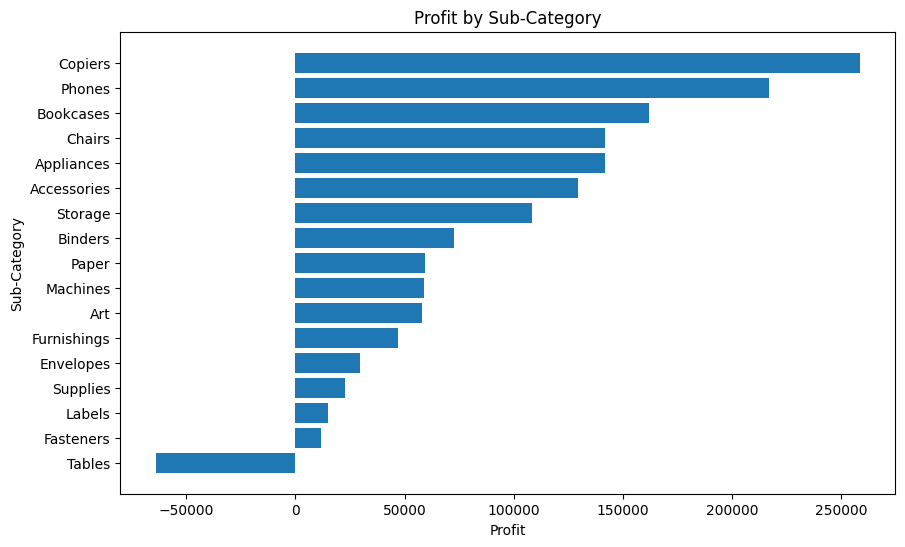

In [439]:
sub_profit = df.groupby('sub_category', as_index=False)['profit'].sum()
sub_profit = sub_profit.sort_values('profit')

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(sub_profit['sub_category'], sub_profit['profit'])

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.show()

Insight:

Observation:  From the above chart, it is clear that while some of the sub-categories are making huge profits, others are making huge losses, as some of the sub-categories have negative total profit.


Explanation:  This implies that all the products are not equally profitable. There are some sub-categories that are incurring huge losses due to high costs, huge discounts, and low demand.

Business Meaning:  The company should therefore watch and correct the sub-categories that are incurring losses in order to enhance profitability.

## **INSIGHT 2 — Profit by Category**

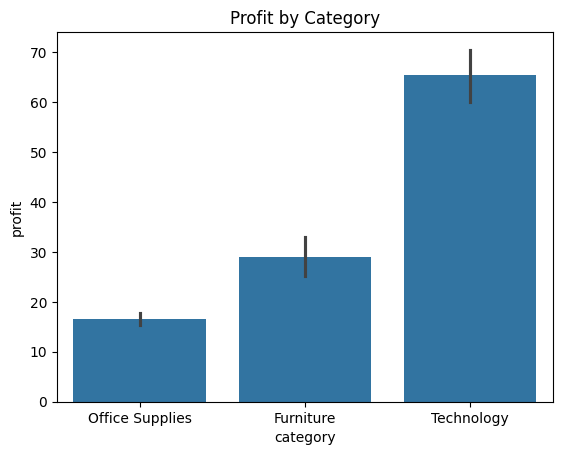

In [440]:
sns.barplot(data=df, x='category', y='profit')
plt.title("Profit by Category")
plt.show()

Insight:

Observation: Profit varies significantly across categories

Explanation: Some categories may have higher costs

Business Meaning: Optimize pricing and cost strategies

## **INSIGHT 3 — Sales by Region**

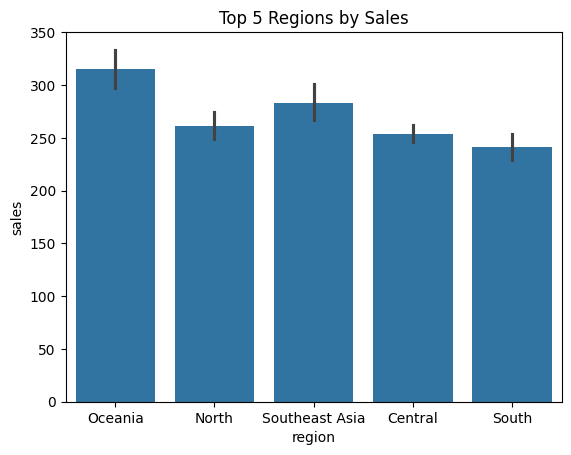

In [441]:
df['sales'] = df['sales'].astype(str).str.replace(',', '', regex=False).astype(float)
top_regions = df.groupby('region')['sales'].sum().nlargest(5).index

df_top = df[df['region'].isin(top_regions)]

sns.barplot(data=df_top, x='region', y='sales')
plt.title("Top 5 Regions by Sales")
plt.show()

nsight:

Observation: Certain regions generate higher sales

Explanation: Regional demand differences

Business Meaning: Focus sales efforts in high-performing regions

## **INSIGHT 4 — Profit by Region**

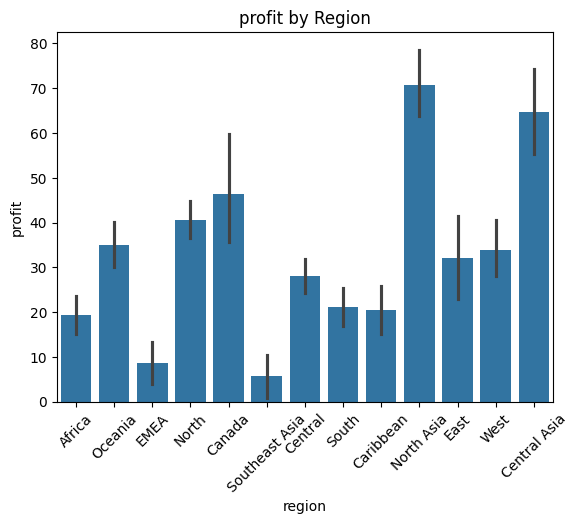

In [442]:
sns.barplot(data=df, x='region', y='profit')
plt.xticks(rotation=45)
plt.title("profit by Region")
plt.show()

Insight:

Observation: Some regions have high sales but low profit

Explanation: High discounts or operational costs

Business Meaning: Improve profitability strategies region-wise

## **INSIGHT 5 — Sales over Time**

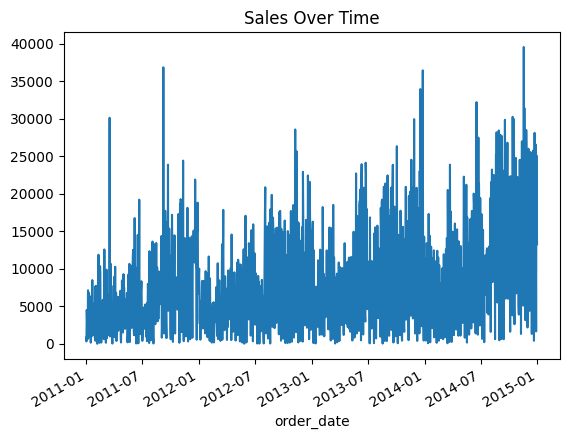

In [443]:
sales_trend = df.groupby('order_date')['sales'].sum()
sales_trend.plot()
plt.title("Sales Over Time")
plt.show()

Insight:

Observation: Sales show fluctuations over time

Explanation: Seasonal demand patterns

Business Meaning: Plan inventory and promotions accordingly

## **INSIGHT 6 — Profit over Time**

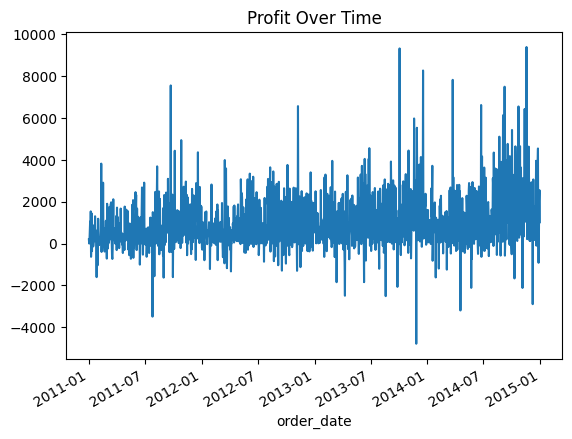

In [444]:
profit_trend = df.groupby('order_date')['profit'].sum()
profit_trend.plot()
plt.title("Profit Over Time")
plt.show()

Insight:

Observation: Profit trend is not always aligned with sales

Explanation: Discounts and costs affect profit

Business Meaning: Monitor profitability separately from sales


## **INSIGHT 7 — Sales vs Profit (Relationship)**

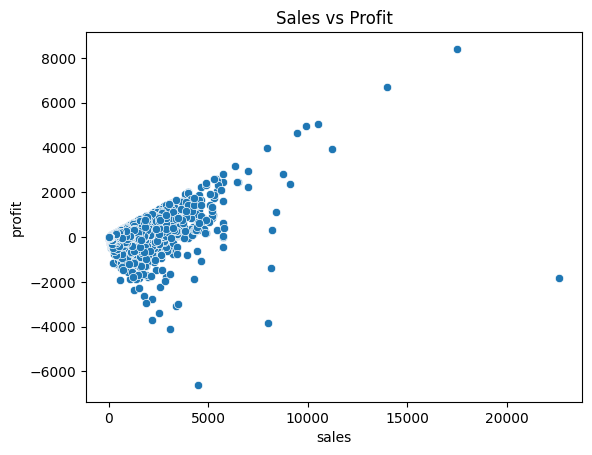

In [445]:
sns.scatterplot(data=df, x='sales', y='profit')
plt.title("Sales vs Profit")
plt.show()

Insight:

Observation: Higher sales do not always mean higher profit

Explanation: Some products have low margins

Business Meaning: Focus on high-margin products

## **INSIGHT 8 — Sales Distribution**

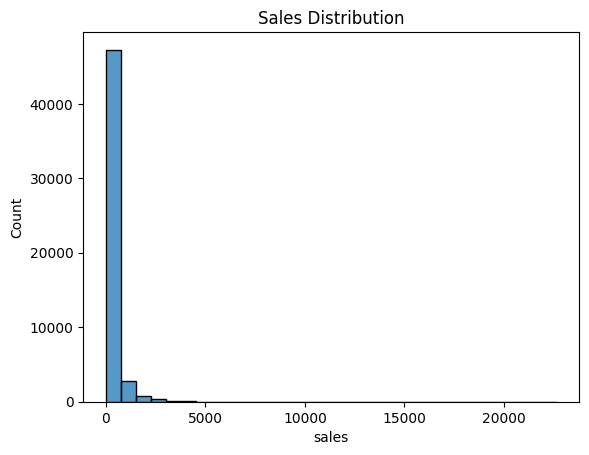

In [446]:
sns.histplot(df['sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

Insight:

Observation: Most sales are low-value transactions

Explanation: High-value sales are less frequent

Business Meaning: Focus on volume-based sales strategies

## **INSIGHT 9 — Profit Distribution**

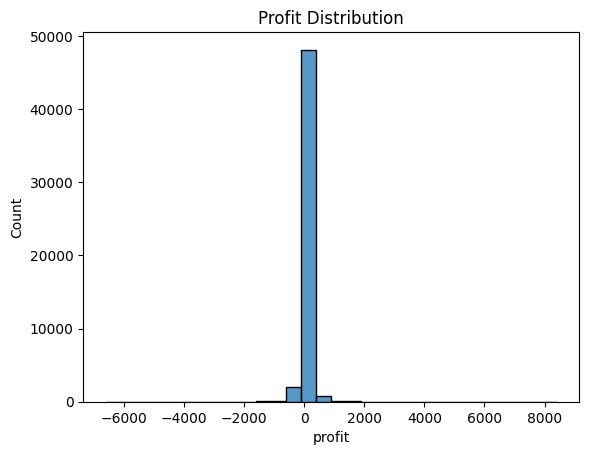

In [447]:
sns.histplot(df['profit'], bins=30)
plt.title("Profit Distribution")
plt.show()


Insight:

Observation: Presence of negative profit values

Explanation: Loss-making transactions exist

Business Meaning: Identify and reduce loss-making products

## **INSIGHT 10 — Sales by Segment**

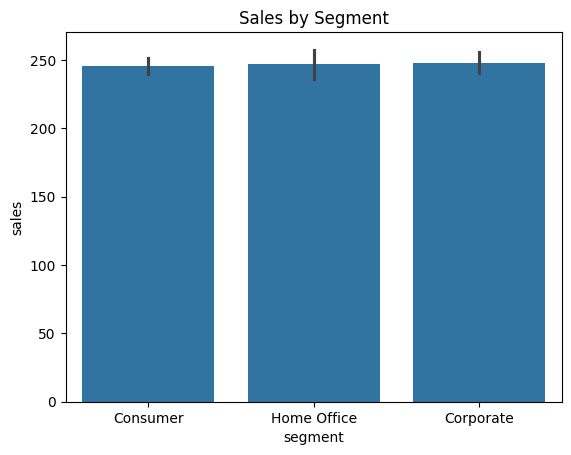

In [448]:
sns.barplot(data=df, x='segment', y='sales')
plt.title("Sales by Segment")
plt.show()

Insight:

Observation: Certain customer segments contribute more revenue

Explanation: Different purchasing behaviors

Business Meaning: Target high-value customer segments

# **Conclusion**

**Key Findings**

The analysis indicates that the category of Technology is performing better in terms of sales. Additionally, it is indicated that profits differ in various categories as well as regions. Some regions as well as customers contribute more to total sales than others. Further, it is indicated in the analysis that an increase in sales does not directly lead to an increase in profits. This is indicated in the analysis.

**Limitations**

The analysis is based on the given data; however, it is not considered how other external factors might influence the market, customers, as well as seasons.

**Recommendations**

Based on the above key findings, it is recommended that the company needs to focus more on the Technology category because it is performing better than other categories. Additionally, it is recommended that the company needs to focus more on increasing profits in various regions as well as eliminating unnecessary costs of various products.

# **Dataset Citation**

https://www.kaggle.com/datasets/thuandao/superstore-sales-analytics

# **Github**


https://github.com/MJSarvajith/Data-Science-Python/blob/main/DataVisualization.ipynb